In [1]:
#Import necessary packages
from pathlib import Path
import xarray as xr
import numpy as np

#File path
BASE = Path("/data/keeling/a/tahsina2/b/LOCA2_Illinois")

files = sorted(BASE.rglob("*.nc"))
print("Number of cropped files:", len(files))
print(files[:5])

Number of cropped files: 182
[PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r1i1p1f1/pr.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r1i1p1f1/pr.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.yearly.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r1i1p1f1/pr.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.yearly.all_mean.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r2i1p1f1/pr.ACCESS-CM2.historical.r2i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.Illinois.nc'), PosixPath('/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r2i1p1f1/pr.ACCESS-CM2.historical.r2i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.yearly.Illinois.nc')]


In [3]:
#Open one file to check
f = files[0]
print(f)

ds = xr.open_dataset(f)
ds

#If you want to open a specific file

# import pandas as pd

# tasks = pd.read_csv("/data/keeling/a/tahsina2/b/loca2_all_tasks.csv")
# tasks.iloc[0]

# row = tasks.iloc[0]

# out_file = (
#     BASE
#     / row["variable"]
#     / row["scenario"]
#     / row["model"]
#     / row["ensemble"]
#     / row["filename"].replace(".nc", ".Illinois.nc")
# )

# print(out_file)
# print(out_file.exists())

/data/keeling/a/tahsina2/b/LOCA2_Illinois/pr/historical/ACCESS-CM2/r1i1p1f1/pr.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20240915.cent.Illinois.nc


<xarray.Dataset> Size: 663MB
Dimensions:  (time: 23741, lat: 93, lon: 75)
Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-12-31T1...
  * lat      (lat) float64 744B 36.84 36.91 36.97 37.03 ... 42.47 42.53 42.59
  * lon      (lon) float64 600B 268.3 268.4 268.5 268.5 ... 272.8 272.9 273.0
Data variables:
    pr       (time, lat, lon) float32 662MB ...
Attributes:
    history:         pierce 2024-09-24 16:21:05.748919 /net/mead24/data/LOCA2...
    LOCA2_version:  v20240915

In [5]:
#Check file information

print(ds.coords)
print(list(ds.data_vars))

Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-12-31T1...
  * lat      (lat) float64 744B 36.84 36.91 36.97 37.03 ... 42.47 42.53 42.59
  * lon      (lon) float64 600B 268.3 268.4 268.5 268.5 ... 272.8 272.9 273.0
['pr']


In [6]:
#Check lat-lon bound
#Illinois bound 36.8, 42.6, -91.7, -87.0
lat = ds["lat"] if "lat" in ds.coords else ds["latitude"]
lon = ds["lon"] if "lon" in ds.coords else ds["longitude"]

print("lat min/max:", float(lat.min()), float(lat.max()))
print("lon min/max:", float(lon.min()), float(lon.max()))
print("time range:", str(ds.time.values[0]), "to", str(ds.time.values[-1]))

lat min/max: 36.84375 42.59375
lon min/max: 268.34375 272.96875
time range: 1950-01-01T12:00:00.000000000 to 2014-12-31T12:00:00.000000000


In [7]:
#Check variables

var = list(ds.data_vars)[0]

print("Variable:", var)
print("Shape:", ds[var].shape)
print("Min:", float(ds[var].min()))
print("Max:", float(ds[var].max()))
print("Mean:", float(ds[var].mean()))
print("Missing values:", int(ds[var].isnull().sum()))

Variable: pr
Shape: (23741, 93, 75)
Min: 0.0
Max: 0.005688634235411882
Mean: 3.151781493215822e-05
Missing values: 3418704


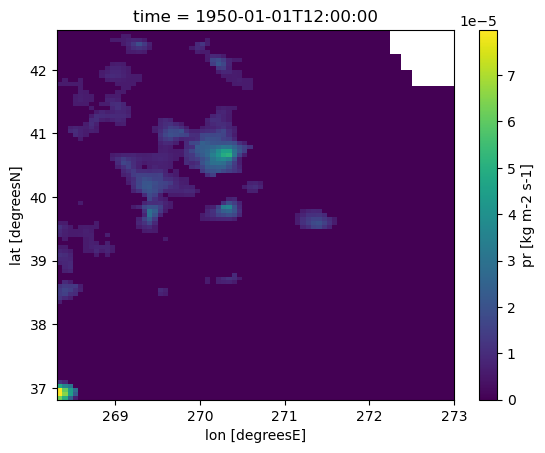

In [8]:
#Map

ds[var].isel(time=0).plot()

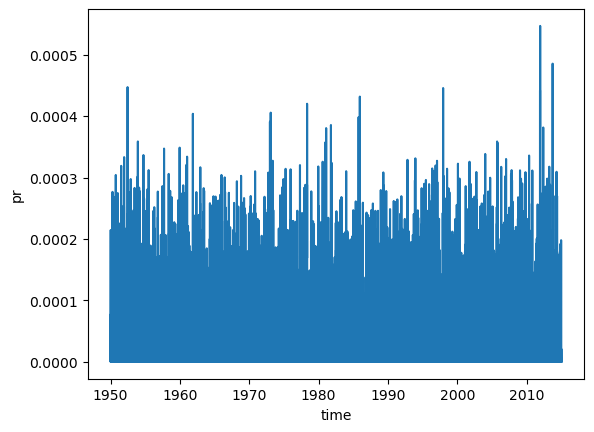

In [9]:
#Time Series

ds[var].mean(dim=[d for d in ds[var].dims if d != "time"]).plot()

In [10]:
ds.close()

In [11]:
#Check how many files have been completed

from pathlib import Path
import pandas as pd

BASE = Path("/data/keeling/a/tahsina2/b")
TASK_CSV = BASE / "loca2_all_tasks.csv"
OUT_BASE = BASE / "LOCA2_Illinois"

tasks = pd.read_csv(TASK_CSV)

def expected_output(row):
    return (
        OUT_BASE
        / row["variable"]
        / row["scenario"]
        / row["model"]
        / row["ensemble"]
        / row["filename"].replace(".nc", ".Illinois.nc")
    )

tasks["out_file"] = tasks.apply(expected_output, axis=1)
tasks["processed"] = tasks["out_file"].apply(lambda p: Path(p).exists() and Path(p).stat().st_size > 0)

total = len(tasks)
done = tasks["processed"].sum()
left = total - done

print(f"Total tasks: {total}")
print(f"Processed: {done}")
print(f"Left: {left}")
print(f"Percent done: {done / total * 100:.2f}%")

Total tasks: 4689
Processed: 199
Left: 4490
Percent done: 4.24%


In [12]:
from pathlib import Path
import pandas as pd

BASE = Path("/data/keeling/a/tahsina2/b")

tasks = pd.read_csv(BASE / "loca2_all_tasks.csv")

processed_sizes = []

for _, row in tasks.iterrows():

    out_file = (
        BASE / "LOCA2_Illinois"
        / row["variable"]
        / row["scenario"]
        / row["model"]
        / row["ensemble"]
        / row["filename"].replace(".nc", ".Illinois.nc")
    )

    if out_file.exists():
        processed_sizes.append(out_file.stat().st_size)

processed_sizes = pd.Series(processed_sizes)

print(f"Processed files: {len(processed_sizes)}")
print(f"Mean size: {processed_sizes.mean()/1024**2:.1f} MB")
print(f"Median size: {processed_sizes.median()/1024**2:.1f} MB")

estimated_total = processed_sizes.mean() * len(tasks)

print(f"Estimated final size: {estimated_total/1024**3:.1f} GB")

Processed files: 243
Mean size: 106.3 MB
Median size: 137.8 MB
Estimated final size: 486.9 GB


In [13]:
from pathlib import Path
import pandas as pd

BASE = Path("/data/keeling/a/tahsina2/b")
tasks = pd.read_csv(BASE/"loca2_all_tasks.csv")

rows = []

for _, row in tasks.iterrows():

    f = (
        BASE/"LOCA2_Illinois"
        / row["variable"]
        / row["scenario"]
        / row["model"]
        / row["ensemble"]
        / row["filename"].replace(".nc",".Illinois.nc")
    )

    if f.exists():
        rows.append({
            "variable": row["variable"],
            "scenario": row["scenario"],
            "size_mb": f.stat().st_size/1024**2
        })

df = pd.DataFrame(rows)

print(df.groupby("variable")["size_mb"].agg(["count","mean","median"]))

          count        mean      median
variable                               
pr          125   47.276387   71.035666
tasmax       64  170.146115  159.009150
tasmin       62  168.394551  159.568235
